# Momentum Engineering (Notebook)

This notebook mirrors `momentum.py` and adds visual checks at each step.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
BASE_DIR = Path(".")
valid_bookings_df = pd.read_parquet(BASE_DIR / "valid_bookings.parquet")
valid_bookings_df.head()

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,adult,end_time,start_time,active,revenue_dollars,booking_date,day_of_week_index,day_of_week,is_outlier,outlier_reason
3,NaN,NaN,NaN,NaN,<NA>,2023-08-13T05:47:00.000000,False,False,False,True,...,1,19:00:00,19:00:00,True,149.93,2025-05-13,1,Tuesday,False,
4,NaN,1.0,0.0,0.0,Web,2023-08-24T12:38:03,False,False,False,True,...,2,19:00:00,19:00:00,True,302.25,2024-06-17,0,Monday,False,
8,NaN,1.0,0.0,0.0,Web,2023-08-26T13:45:03,False,False,False,True,...,3,19:00:00,19:00:00,True,590.36,2024-06-06,3,Thursday,False,
10,NaN,NaN,NaN,1.0,Web,2023-09-22T03:57:13,False,False,False,True,...,2,18:00:00,17:00:00,True,199.60,2024-03-28,3,Thursday,False,
11,NaN,1.0,0.0,0.0,iOS,2023-09-25T03:09:57,False,False,False,True,...,7,18:00:00,18:00:00,True,1057.87,2025-12-18,3,Thursday,False,


In [2]:
#remove outliers from restaurant_id based on google sheet 
outlier_ids = [4503, 4502, 933, 837]
valid_bookings_df = valid_bookings_df[~valid_bookings_df['restaurant_id'].isin(outlier_ids)]
valid_bookings_df.shape


(452349, 29)

In [3]:
BASE_PATH = Path.cwd().parent.parent
PARQUET_PATH = BASE_PATH / "data" / "mv_dataset_parquet"
restaurants = pd.read_parquet(PARQUET_PATH / "restaurants.parquet")
restaurants.shape

(2474, 3)

In [4]:
valid_bookings_df = valid_bookings_df.merge(restaurants, on="restaurant_id", how="left")
valid_bookings_df.head()

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,start_time,active,revenue_dollars,booking_date,day_of_week_index,day_of_week,is_outlier,outlier_reason,name,days_in_advance
0,NaN,NaN,NaN,1.0,Web,2023-09-22T03:57:13,False,False,False,True,...,17:00:00,True,199.6,2024-03-28,3,Thursday,False,,Vantage Point QSNCC,180.0
1,1.0,NaN,0.0,1.0,Web,2023-10-16T13:37:18,False,False,False,True,...,19:00:00,True,232.8,2024-02-10,5,Saturday,False,,Place Bangkok,90.0
2,NaN,NaN,0.0,0.0,iOS,2023-10-24T14:44:53,False,False,False,True,...,17:00:00,True,1119.8,2024-01-20,5,Saturday,False,,Chatrium Hotel Riverside Bangkok Staycation,90.0
3,1.0,NaN,0.0,0.0,Web,2023-10-25T09:38:08,False,False,False,True,...,14:00:00,True,180.0,2024-03-30,5,Saturday,False,,<NA>,NaN
4,NaN,NaN,0.0,1.0,iOS,2023-10-28T04:42:45,False,False,False,True,...,18:00:00,True,199.6,2024-01-21,6,Sunday,False,,Vantage Point QSNCC,180.0


In [5]:
#retrieve places api data from csv
CSV_PATH = BASE_PATH / "_1_eda" / "places_api_new_results.csv"

# Load the CSV
google_restaurants_df = pd.read_csv(CSV_PATH)
google_restaurants_df.shape

(2392, 12)

In [6]:
valid_bookings_df = valid_bookings_df.merge(google_restaurants_df, left_on='name', right_on='input_string', how='left')
valid_bookings_df.head()

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,official_name,city,country,formatted_address,rating,website,error,Cuisine,Cuisine_confidence,raw_types
0,NaN,NaN,NaN,1.0,Web,2023-09-22T03:57:13,False,False,False,True,...,Vantage Point,NaN,Thailand,ชั้น 2 เลขที่ 60 Queen Sirikit National Conven...,4.2,https://www.facebook.com/VantagePointRestaurante,API key not valid. Please pass a valid API key.,General,0.15,"buffet_restaurant,restaurant,food,point_of_int..."
1,1.0,NaN,0.0,1.0,Web,2023-10-16T13:37:18,False,False,False,True,...,place.bangkok,NaN,Thailand,"73/3 ซอย อินทามระ 4 Khwaeng Samsen Nai, Khet P...",4.4,https://www.facebook.com/placebangkok/,API key not valid. Please pass a valid API key.,Italian,0.70,"italian_restaurant,restaurant,point_of_interes..."
2,NaN,NaN,0.0,0.0,iOS,2023-10-24T14:44:53,False,False,False,True,...,Chatrium Hotel Riverside Bangkok,NaN,Thailand,"28 ถ. เจริญกรุง Khwaeng Wat Phraya Krai, Khet ...",4.6,https://www.chatrium.com/chatriumriversidebang...,API key not valid. Please pass a valid API key.,NaN,0.20,"hotel,lodging,point_of_interest,establishment"
3,1.0,NaN,0.0,0.0,Web,2023-10-25T09:38:08,False,False,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,0.0,1.0,iOS,2023-10-28T04:42:45,False,False,False,True,...,Vantage Point,NaN,Thailand,ชั้น 2 เลขที่ 60 Queen Sirikit National Conven...,4.2,https://www.facebook.com/VantagePointRestaurante,API key not valid. Please pass a valid API key.,General,0.15,"buffet_restaurant,restaurant,food,point_of_int..."


In [7]:
# 1. Create a deep copy to avoid SettingWithCopy warnings
clean_bookings_df = valid_bookings_df.copy()

# 2. Count before for your records
initial_count = len(clean_bookings_df)
print (f"Initial records: {initial_count}")

# 3. Drop records where user_id_masked is an empty string or NaN
clean_bookings_df = clean_bookings_df[
    (clean_bookings_df['user_id_masked'] != "") & 
    (clean_bookings_df['user_id_masked'].notna())
]

# 4. Verification
removed_count = initial_count - len(clean_bookings_df)
print(f"Removed {removed_count} records with empty or null user_id_masked.")
print(f"Remaining records: {len(clean_bookings_df)}")

Initial records: 452349
Removed 135856 records with empty or null user_id_masked.
Remaining records: 316493


In [8]:
# The 'Gold Standard' for identifying these specific system duplicates
logic_columns = [
    'user_id_masked', 
    'restaurant_id', 
    'booking_date', 
    'start_time', 
    'end_time', 
    'active'
]

# Identify the duplicates
duplicate_mask = clean_bookings_df.duplicated(subset=logic_columns, keep=False)
duplicates_only = clean_bookings_df[duplicate_mask].sort_values(by=['user_id_masked', 'id'])

# Count them
unique_duplicate_events = duplicates_only.groupby(logic_columns).ngroups

print(f"Identified {unique_duplicate_events} events that have redundant system entries.")

Identified 2720 events that have redundant system entries.


In [9]:
# Select only the identifying columns to verify they are identical
verification_cols = ['id', 'user_id_masked', 'restaurant_id', 'booking_date', 'start_time', 'end_time', 'revenue_dollars', 'active']

# View the top 20 duplicates with these specific columns
duplicates_only[verification_cols].head(20)

,id,user_id_masked,restaurant_id,booking_date,start_time,end_time,revenue_dollars,active
279293,7485531,10004982607977776954,894,2025-05-11,13:00:00,15:00:00,226.40,True
279295,7485538,10004982607977776954,894,2025-05-11,13:00:00,15:00:00,136.00,True
163625,6392572,1002398865849034957,2592,2024-11-13,18:00:00,18:00:00,1099.00,True
163630,6392601,1002398865849034957,2592,2024-11-13,18:00:00,18:00:00,769.30,True
327266,7755687,10038524973759102977,4385,2025-07-26,18:00:00,20:00:00,76.56,True
327276,7755712,10038524973759102977,4385,2025-07-26,18:00:00,20:00:00,76.56,True
81665,5264161,10049410200564458075,3279,2024-07-07,12:00:00,12:00:00,99.90,True
81667,5264174,10049410200564458075,3279,2024-07-07,12:00:00,12:00:00,99.90,True
81668,5264186,10049410200564458075,3279,2024-07-07,12:00:00,12:00:00,99.90,True
236,3991557,10050903249521646579,2001,2024-02-04,12:00:00,14:00:00,1505.00,True


In [10]:
# We sort by ID descending so the highest ID appears first for each group
final_bookings_df = clean_bookings_df.sort_values('id', ascending=False).drop_duplicates(
    subset=logic_columns, 
    keep='first'
)

In [11]:
# Calculate the IDs that were removed (the "old_transaction_ids")
all_ids = set(clean_bookings_df['id'])
kept_ids = set(final_bookings_df['id'])
old_transaction_ids = list(all_ids - kept_ids)

print(f"Original Records: {len(clean_bookings_df)}")
print(f"Cleaned Records: {len(final_bookings_df)}")
print(f"Total 'Old' IDs identified for deletion: {len(old_transaction_ids)}")

Original Records: 316493
Cleaned Records: 313276
Total 'Old' IDs identified for deletion: 3149


In [13]:
final_bookings_df['country'].value_counts()

country
Thailand           241311
Singapore            3315
United States         350
Hong Kong             230
France                205
Malaysia              121
India                  48
Indonesia              21
Canada                 20
Netherlands            19
United Kingdom         13
Nigeria                10
North Macedonia        10
Brazil                  8
Italy                   8
Japan                   8
Australia               7
Vietnam                 6
Greece                  3
New Zealand             1
Portugal                1
Name: count, dtype: int64

In [14]:
# Filter the DataFrame to strictly keep 'Thailand'
final_bookings_df = final_bookings_df[final_bookings_df['country'] == 'Thailand']

# 3. Verify the filter worked
print("\n--- After Filtering ---")
print(final_bookings_df['country'].value_counts())


--- After Filtering ---
country
Thailand    241311
Name: count, dtype: int64


## 0) Guardrails / required cols

In [15]:
import pandas as pd
import numpy as np
import requests

# 1. Setup Currency Reference
country_to_currency = {
    'Thailand': 'THB', 'Singapore': 'SGD', 'Malaysia': 'MYR',
    'United States': 'USD', 'Japan': 'JPY', 'Hong Kong': 'HKD',
    'United Kingdom': 'GBP', 'Australia': 'AUD', 'Vietnam': 'VND',
    'Indonesia': 'IDR', 'India': 'INR', 'France': 'EUR',
    'Italy': 'EUR', 'Netherlands': 'EUR'
}

# 2. Fetch Live Rates (Base currency is now THB)
def get_live_rates(base_currency='THB'):
    url = f"https://open.er-api.com/v6/latest/{base_currency}"
    try:
        response = requests.get(url)
        data = response.json()
        if data['result'] == 'success':
            return data['rates']
    except Exception as e:
        print(f"API Error: {e}")
        
    # Fallback to approx rates (1 THB = X Target Currency)
    print("Using fallback rates...")
    return {
        'THB': 1.0, 'SGD': 0.038, 'MYR': 0.13, 
        'JPY': 4.2, 'USD': 0.028, 'EUR': 0.026
    }

# Get rates relative to THB
exchange_rates_to_thb = get_live_rates('THB')

# 3. Clean and Validate DataFrame
required_cols = ["restaurant_id", "booking_date", "id", "revenue_dollars", "country"]
missing = [c for c in required_cols if c not in final_bookings_df.columns]
if missing:
    raise ValueError(f"final_bookings_df missing required columns: {missing}")

# Handle Dates and NaNs
final_bookings_df["booking_date"] = pd.to_datetime(final_bookings_df["booking_date"], errors="coerce")
final_bookings_df = final_bookings_df.dropna(subset=["booking_date", "restaurant_id"])

# 4. Apply Currency Conversion (To THB)
def perform_conversion_to_thb(row):
    country = row.get('country')
    amount = row.get('revenue_dollars') # Assuming this column actually holds the raw local currency
    
    currency_code = country_to_currency.get(country)
    
    if currency_code and pd.notnull(amount):
        # The API returns "1 THB = X Local Currency"
        # Example: 1 THB = 1 THB (rate is 1.0)
        # To convert Local to THB: amount / rate
        rate = exchange_rates_to_thb.get(currency_code)
        if rate:
            return amount / rate
            
    return amount

# Rename the output column to reflect the new currency
final_bookings_df["revenue_thb"] = final_bookings_df.apply(perform_conversion_to_thb, axis=1)

# 5. Handle Guest Logic
if "total_guests" not in final_bookings_df.columns:
    if "adult" in final_bookings_df.columns and "kids" in final_bookings_df.columns:
        final_bookings_df["total_guests"] = (
            final_bookings_df["adult"].fillna(0) + final_bookings_df["kids"].fillna(0)
        )
    else:
        final_bookings_df["total_guests"] = np.nan

print(f"Final Shape: {final_bookings_df.shape}")

Final Shape: (241311, 45)


In [16]:
final_bookings_df.head(10)

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,country,formatted_address,rating,website,error,Cuisine,Cuisine_confidence,raw_types,revenue_thb,total_guests
452348,NaN,NaN,0.0,0.0,Android,2026-01-07T04:50:49,False,False,False,True,...,Thailand,"B Floor, Banyan Tree Bangkok, 21/100 S Sathon ...",4.6,https://www.banyantree.com/thailand/bangkok/di...,API key not valid. Please pass a valid API key.,Thai,0.70,"buffet_restaurant,thai_restaurant,asian_restau...",79.90,1
452346,NaN,NaN,0.0,0.0,iOS,2026-01-07T04:50:12,False,False,False,True,...,Thailand,"Siphya, 2 ถ. เจริญกรุง แขวงบางรัก เขตบางรัก กร...",4.5,https://www.marriott.com/en-us/dining/restaura...,API key not valid. Please pass a valid API key.,Italian,0.70,"italian_restaurant,restaurant,food,point_of_in...",139.00,2
452343,NaN,NaN,0.0,0.0,Web,2026-01-07T04:47:17,False,False,False,True,...,Thailand,"Kimpton Maa-Lai Bangkok, Soi Ton Son, Khwaeng ...",4.7,https://bit.ly/GGStockRoom,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,food,point_of_interest,establishment",198.00,2
452340,1.0,NaN,0.0,0.0,iOS,2026-01-07T04:46:48,False,False,False,True,...,Thailand,"55 ถนน ศรีนครินทร์ Khwaeng Nong Bon, Khet Praw...",4.7,http://www.boontongkeethailand.com/home/out-ou...,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,food,point_of_interest,establishment",138.00,4
452338,1.0,NaN,0.0,0.0,Android,2026-01-07T04:45:14,False,False,False,True,...,Thailand,"Queen Sirikit National Convention Center, 60 T...",4.1,https://foa.co.th/,API key not valid. Please pass a valid API key.,Chinese,0.70,"chinese_restaurant,restaurant,point_of_interes...",352.50,4
452336,NaN,1.0,0.0,0.0,iOS,2026-01-07T04:43:41,False,False,False,True,...,Thailand,"1 Rachadaphisek Road, Fortune Town, แขวงดินแดง...",4.4,NaN,API key not valid. Please pass a valid API key.,Chinese,0.70,"chinese_restaurant,restaurant,food,point_of_in...",95.88,1
452334,NaN,NaN,0.0,0.0,iOS,2026-01-07T04:41:50,False,False,False,True,...,Thailand,"166, 1-5 ถนน รัชดา 10 Khwaeng Huai Khwang, Khe...",4.4,https://www.facebook.com/kuangseafood2,API key not valid. Please pass a valid API key.,Seafood,0.70,"seafood_restaurant,restaurant,point_of_interes...",912.00,8
452332,NaN,1.0,0.0,0.0,iOS,2026-01-07T04:38:50,False,False,False,True,...,Thailand,เลขที่ 9/8-9 Kagonoya ชั้น 7 ห้อง 730 Thanon R...,3.3,https://m.facebook.com/kagonoyathailand,API key not valid. Please pass a valid API key.,Japanese,0.70,"japanese_restaurant,restaurant,food,point_of_i...",388.50,5
452331,NaN,NaN,0.0,0.0,Android,2026-01-07T04:37:46,False,False,False,True,...,Thailand,"24th floor, Centara Grand and Bangkok Conventi...",4.3,https://www.ventisibangkok.com/,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,point_of_interest,food,establishment",792.00,8
452330,NaN,NaN,0.0,0.0,Web,2026-01-07T04:35:34,False,False,False,True,...,Thailand,"Ground Level Chatrium 728 Thanon Phetchaburi, ...",4.7,https://www.chatrium.com/grandbangkok/savio,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,point_of_interest,food,establishment",225.00,3


In [19]:
final_bookings_df.columns

Index(['has_promptpay', 'has_cc', 'has_shopee_pay', 'has_special_request',
       'medium', 'created_at', 'prepared', 'refund', 'adjusted', 'ack', 'id',
       'restaurant_id', 'is_temporary', 'for_locking_system', 'no_show',
       'arrived', 'channel', 'user_id_masked', 'kids', 'adult', 'end_time',
       'start_time', 'active', 'revenue_dollars', 'booking_date',
       'day_of_week_index', 'day_of_week', 'is_outlier', 'outlier_reason',
       'name', 'days_in_advance', 'input_string', 'found', 'official_name',
       'city', 'country', 'formatted_address', 'rating', 'website', 'error',
       'Cuisine', 'Cuisine_confidence', 'raw_types', 'revenue_thb',
       'total_guests', 'year_month'],
      dtype='object')

In [17]:
final_bookings_df.to_parquet("valid_bookings_with_currency_and_google_restaurants_without_duplicates.parquet")

## 1) Monthly aggregation

In [20]:
final_bookings_df["year_month"] = final_bookings_df["booking_date"].dt.to_period("M").dt.to_timestamp()

# Filter out advance bookings beyond Feb 2026
cutoff_month = pd.Timestamp("2026-01-31")
final_bookings_df = final_bookings_df[final_bookings_df["year_month"] <= cutoff_month].copy()

restaurants_agg = (
    final_bookings_df
    .groupby(["name", "year_month"], as_index=False)
    .agg(
        monthly_bookings=("id", "count"),
        monthly_revenue=("revenue_thb", "sum"),
        avg_revenue_per_booking=("revenue_thb", "mean"),
        avg_guests=("total_guests", "mean"),
        active_days=("booking_date", lambda x: x.dt.date.nunique()),
    )
)

#do note monthly_revenue here refers to the usd denominated revenue, please confirm based on above steps 
restaurants_agg["monthly_bookings"] = restaurants_agg["monthly_bookings"].fillna(0).astype(int)
restaurants_agg["monthly_revenue"] = restaurants_agg["monthly_revenue"].fillna(0.0)
restaurants_agg["avg_revenue_per_booking"] = restaurants_agg["avg_revenue_per_booking"].replace([np.inf, -np.inf], np.nan)
restaurants_agg["avg_revenue_per_booking"] = restaurants_agg["avg_revenue_per_booking"].fillna(0.0)

restaurants_agg = restaurants_agg.sort_values(["name", "year_month"]).reset_index(drop=True)
restaurants_agg.head()

,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days
0,Charoen Rung Rueang International Buffet MS S...,2024-08-01,7,3198.4,456.914286,2.285714,6
1,Charoen Rung Rueang International Buffet MS S...,2024-10-01,32,21789.1,680.909375,3.406250,19
2,Charoen Rung Rueang International Buffet MS S...,2024-11-01,21,12593.7,599.700000,3.000000,17
3,Charoen Rung Rueang International Buffet MS S...,2024-12-01,21,15592.2,742.485714,3.714286,11
4,Charoen Rung Rueang International Buffet MS S...,2025-01-01,20,10594.7,529.735000,2.650000,14


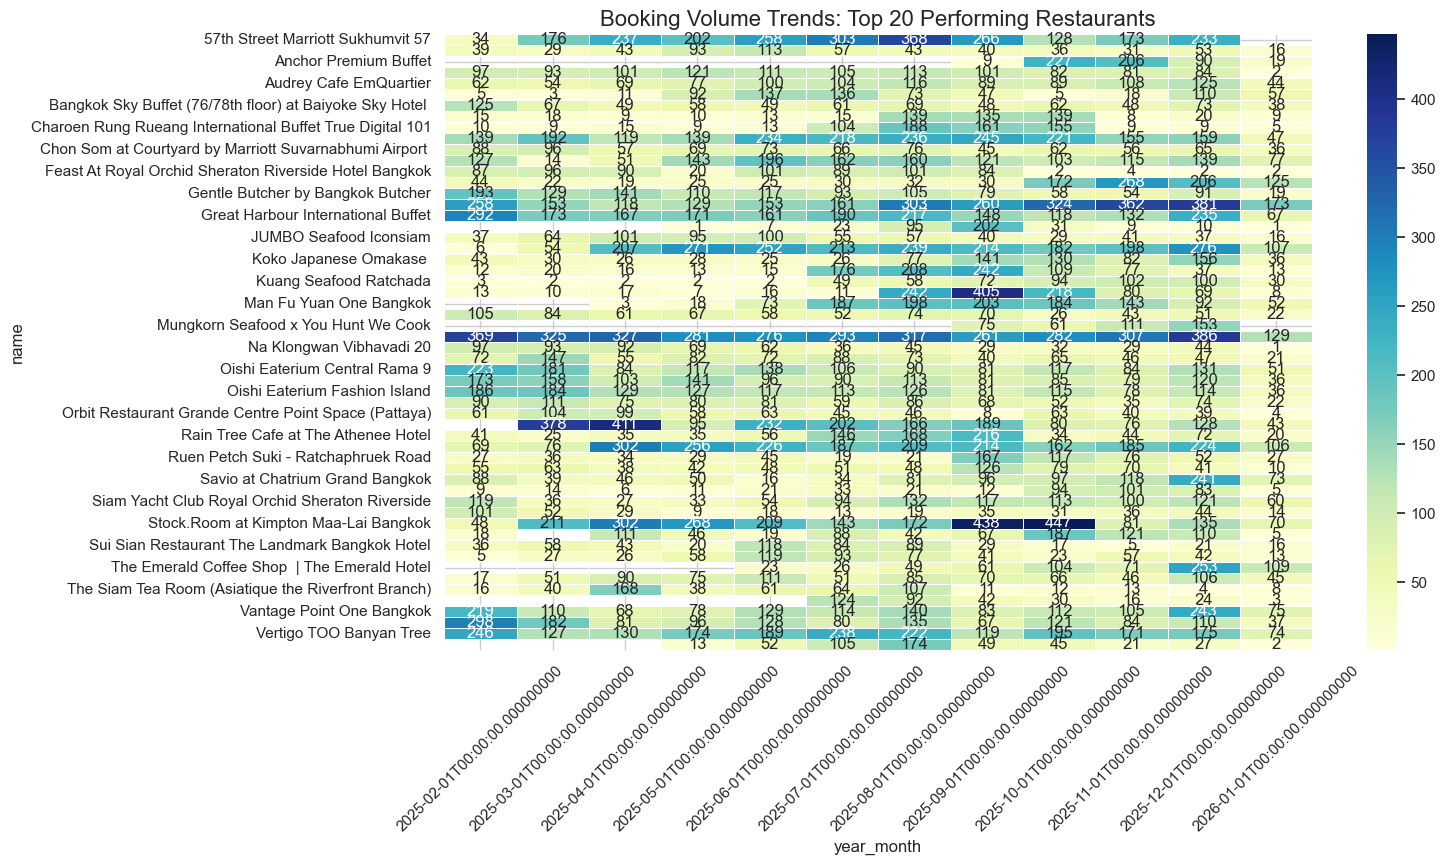

In [21]:
start_date = cutoff_month - pd.DateOffset(months=12)

# 2. Filter for the last 12 months
last_12_months_df = restaurants_agg[
    (restaurants_agg["year_month"] >= start_date) & 
    (restaurants_agg["year_month"] <= cutoff_month)
].copy()

# 3. Extract top 20 for each month
top_20_per_month = (
    last_12_months_df.sort_values(["year_month", "monthly_bookings"], ascending=[True, False])
    .groupby("year_month")
    .head(20)
)

# 1. Get the list of restaurant names that were ever in a Top 20 in the last 12 months
top_restaurants = top_20_per_month['name'].unique()

# 2. Pivot the data: Rows = Restaurants, Cols = Months, Values = Bookings
heatmap_data = last_12_months_df[last_12_months_df['name'].isin(top_restaurants)].pivot(
    index='name', 
    columns='year_month',
    values='monthly_bookings'
)

# 3. Plot
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
plt.title("Booking Volume Trends: Top 20 Performing Restaurants", fontsize=16)
plt.xticks(rotation=45)
plt.show()


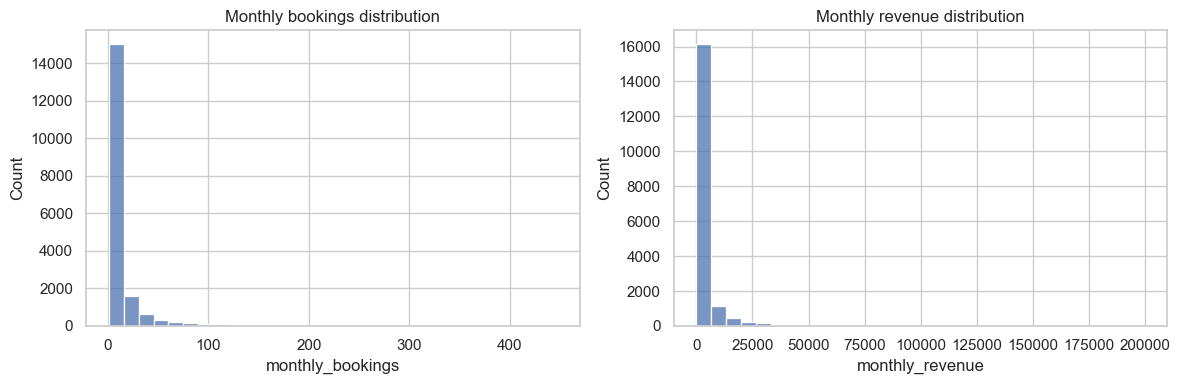

In [22]:
# Plot bookings and revenue distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(restaurants_agg["monthly_bookings"], bins=30, ax=axes[0])
axes[0].set_title("Monthly bookings distribution")

sns.histplot(restaurants_agg["monthly_revenue"], bins=30, ax=axes[1])
axes[1].set_title("Monthly revenue distribution")
plt.tight_layout()

## 2) Minimum history filter

In [23]:
# 1. Determine the "Analysis Date" (The latest date in your entire dataset)
analysis_end_date = restaurants_agg['year_month'].max()
print (f"Analysis End Date: {analysis_end_date}")
# 2. Define the Cutoff (12 Months Ago)
# Anyone whose LAST record is older than this date is considered "Churned"
cutoff_date = analysis_end_date - pd.DateOffset(months=12)
print (f"Cutoff Date: {cutoff_date}")

# 3. Identify "Active" Restaurants
# We group by name and check the MAX date for each restaurant.
# If their max date is >= cutoff, they are active.
latest_activity = restaurants_agg.groupby('name')['year_month'].max()
active_restaurants = latest_activity[latest_activity >= cutoff_date].index

# 4. Filter the Main Dataframe
# We keep ALL rows (history) for active restaurants, and drop everything for churned ones.
restaurants_agg_active = restaurants_agg[restaurants_agg['name'].isin(active_restaurants)].copy()

# 5. Summary of what happened
original_count = restaurants_agg['name'].nunique()
new_count = restaurants_agg_active['name'].nunique()
dropped_count = original_count - new_count

print(f"--- Filter Summary ---")
print(f"Total Restaurants:      {original_count}")
print(f"Active (Last 12m):      {new_count}")
print(f"Dropped (Churned):      {dropped_count} restaurants removed.")

Analysis End Date: 2026-01-01 00:00:00
Cutoff Date: 2025-01-01 00:00:00
--- Filter Summary ---
Total Restaurants:      1735
Active (Last 12m):      1693
Dropped (Churned):      42 restaurants removed.


In [24]:
restaurants_agg_active

,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days
0,Charoen Rung Rueang International Buffet MS S...,2024-08-01,7,3198.4,456.914286,2.285714,6
1,Charoen Rung Rueang International Buffet MS S...,2024-10-01,32,21789.1,680.909375,3.406250,19
2,Charoen Rung Rueang International Buffet MS S...,2024-11-01,21,12593.7,599.700000,3.000000,17
3,Charoen Rung Rueang International Buffet MS S...,2024-12-01,21,15592.2,742.485714,3.714286,11
4,Charoen Rung Rueang International Buffet MS S...,2025-01-01,20,10594.7,529.735000,2.650000,14
...,...,...,...,...,...,...,...
18425,sala ayutthaya staycation (Ayutthaya),2025-06-01,1,468.0,468.000000,2.000000,1
18426,sala ayutthaya staycation (Ayutthaya),2025-10-01,1,468.0,468.000000,2.000000,1
18427,sala bang pa-in Staycation (Ayutthaya),2025-09-01,2,1560.0,780.000000,3.500000,2
18428,sala bang pa-in Staycation (Ayutthaya),2025-10-01,1,2496.0,2496.000000,12.000000,1


## 4) Growth + rolling growth

                                                    name  booking_growth_pct
0       Charoen Rung Rueang International Buffet MS S...            0.000000
1       Charoen Rung Rueang International Buffet MS S...            3.571429
2       Charoen Rung Rueang International Buffet MS S...           -0.343750
3       Charoen Rung Rueang International Buffet MS S...            0.000000
4       Charoen Rung Rueang International Buffet MS S...           -0.047619
...                                                  ...                 ...
18425              sala ayutthaya staycation (Ayutthaya)            0.000000
18426              sala ayutthaya staycation (Ayutthaya)            0.000000
18427             sala bang pa-in Staycation (Ayutthaya)            0.000000
18428             sala bang pa-in Staycation (Ayutthaya)           -0.500000
18429                                     อร่อย Together            0.000000

[18334 rows x 2 columns]
                                                  

C:\Users\foogu\AppData\Local\Temp\ipykernel_15972\3160821525.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


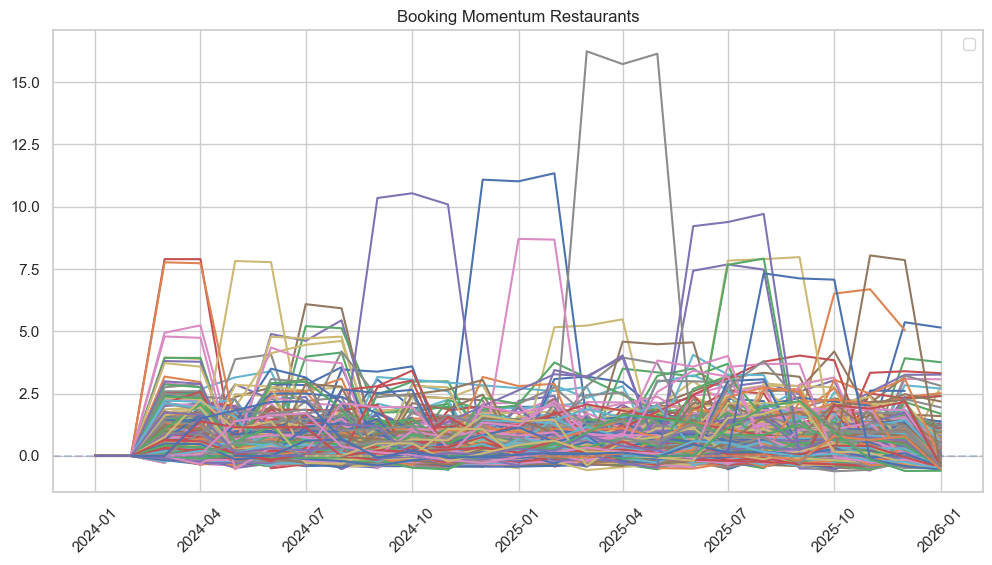

In [25]:
# 1. Define a "Ceiling" for growth
# If a normal high-growth restaurant doubles (100%), let's set the cap for 'Infinity' a bit higher
# to show that starting from zero is amazing, but not infinitely so.
# 2.0 = 200% growth.
MAX_GROWTH_CAP = 2.0 

restaurants_agg_active["booking_growth_pct"] = (
    restaurants_agg_active.groupby("name")["monthly_bookings"]
    .pct_change()
    .replace([np.inf], MAX_GROWTH_CAP)  # Replace Infinity with 200% (The 'Superstar' cap)
    .fillna(0)                          # Replace NaN (start of data) with 0
)

print(restaurants_agg_active[["name","booking_growth_pct"]])

restaurants_agg_active["revenue_growth_pct"] = (
    restaurants_agg_active.groupby("name")["monthly_revenue"]
    .pct_change()
    .replace([np.inf], MAX_GROWTH_CAP)  # Replace Infinity with 200% (The 'Superstar' cap)
    .fillna(0)                          # Replace NaN (start of data) with 0
)

print(restaurants_agg_active[["name","revenue_growth_pct"]])

ROLL = 3
restaurants_agg_active["booking_growth_rolling"] = (
    restaurants_agg_active.groupby("name")["booking_growth_pct"]
    .rolling(ROLL, min_periods=ROLL)
    .mean()
    .reset_index(level=0, drop=True)
)

print(restaurants_agg_active[["name","booking_growth_rolling"]])


restaurants_agg_active["revenue_growth_rolling"] = (
    restaurants_agg_active.groupby("name")["revenue_growth_pct"]
    .rolling(ROLL, min_periods=ROLL)
    .mean()
    .reset_index(level=0, drop=True)
)
print(restaurants_agg_active[["name","revenue_growth_rolling"]])

restaurants_agg_active["booking_growth_rolling"] = restaurants_agg_active["booking_growth_rolling"].fillna(0.0)
restaurants_agg_active["revenue_growth_rolling"] = restaurants_agg_active["revenue_growth_rolling"].fillna(0.0)

restaurants_agg_active[["booking_growth_rolling","revenue_growth_rolling"]].describe().T

import matplotlib.pyplot as plt


latest = restaurants_agg_active.sort_values("year_month").groupby("name").tail(1)

top_movers = (
    latest
    .sort_values("booking_growth_rolling", ascending=False)["name"]
)

plt.figure(figsize=(12,6))

for name in top_movers:
    df = restaurants_agg_active[restaurants_agg_active["name"] == name]
    plt.plot(df["year_month"], df["booking_growth_rolling"])

plt.axhline(0, linestyle="--", alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.title("Booking Momentum Restaurants")
plt.show()



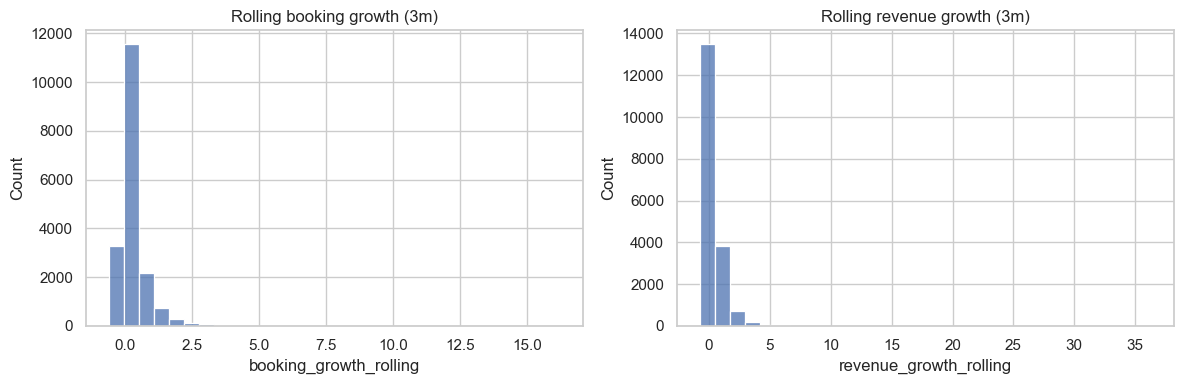

In [26]:
# Growth distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(restaurants_agg_active["booking_growth_rolling"], bins=30, ax=axes[0])
axes[0].set_title("Rolling booking growth (3m)")

sns.histplot(restaurants_agg_active["revenue_growth_rolling"], bins=30, ax=axes[1])
axes[1].set_title("Rolling revenue growth (3m)")
plt.tight_layout()

C:\Users\foogu\AppData\Local\Temp\ipykernel_15972\3796667373.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\foogu\AppData\Local\Temp\ipykernel_15972\3796667373.py:26: UserWarning: Glyph 24565 (\N{CJK UNIFIED IDEOGRAPH-5FF5}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\foogu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24565 (\N{CJK UNIFIED IDEOGRAPH-5FF5}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


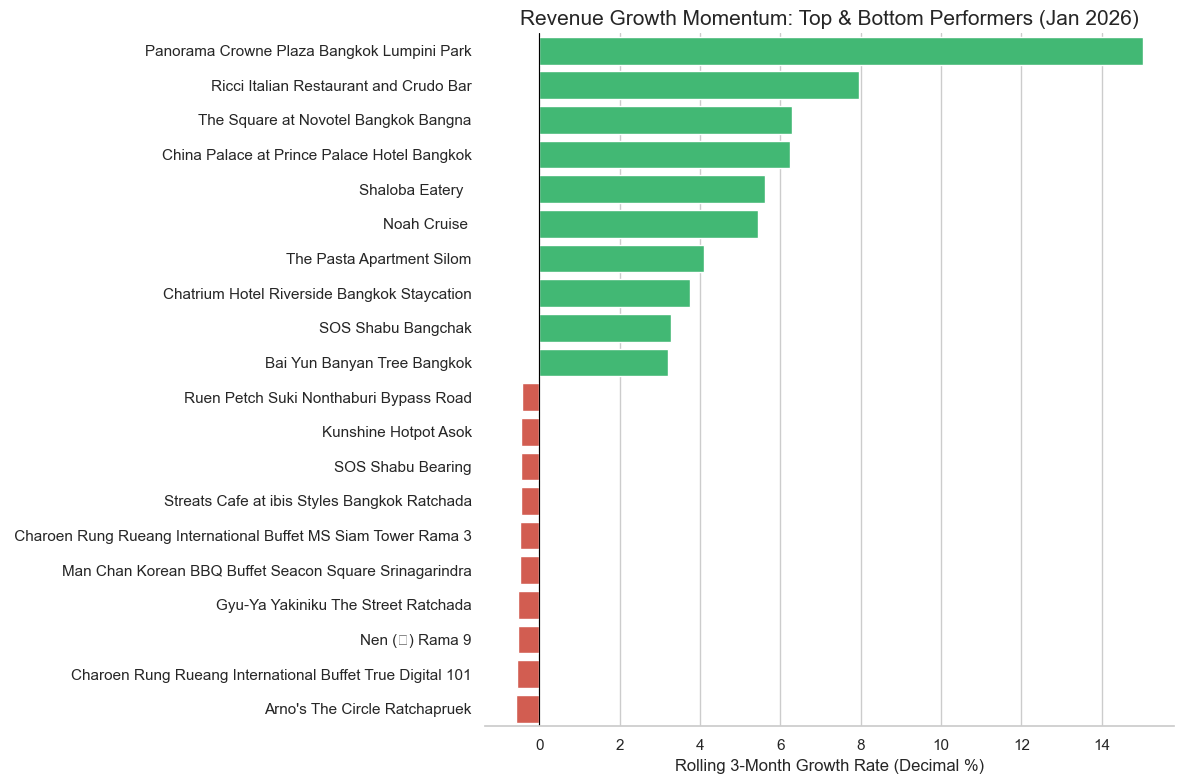

In [27]:
# 1. Get the most recent month's data (Jan 2026)
latest_month_label = restaurants_agg_active['year_month'].max()
latest_growth = restaurants_agg_active[restaurants_agg_active['year_month'] == latest_month_label].copy()

# 2. Identify Top 10 and Bottom 10 by Revenue Growth
top_growth = latest_growth.nlargest(10, "revenue_growth_rolling")
bottom_growth = latest_growth.nsmallest(10, "revenue_growth_rolling")
leaderboard = pd.concat([top_growth, bottom_growth]).sort_values("revenue_growth_rolling", ascending=False)

# 3. Plot
plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in leaderboard['revenue_growth_rolling']]

sns.barplot(
    data=leaderboard,
    x="revenue_growth_rolling",
    y="name",
    palette=colors
)

plt.axvline(0, color='black', linewidth=0.8) # Zero line for reference
plt.title(f"Revenue Growth Momentum: Top & Bottom Performers ({latest_month_label.strftime('%b %Y')})", fontsize=15)
plt.xlabel("Rolling 3-Month Growth Rate (Decimal %)", fontsize=12)
plt.ylabel("")
sns.despine(left=True)
plt.tight_layout()
plt.show()

(233, 7)
Shape after correct merge: (233, 9)


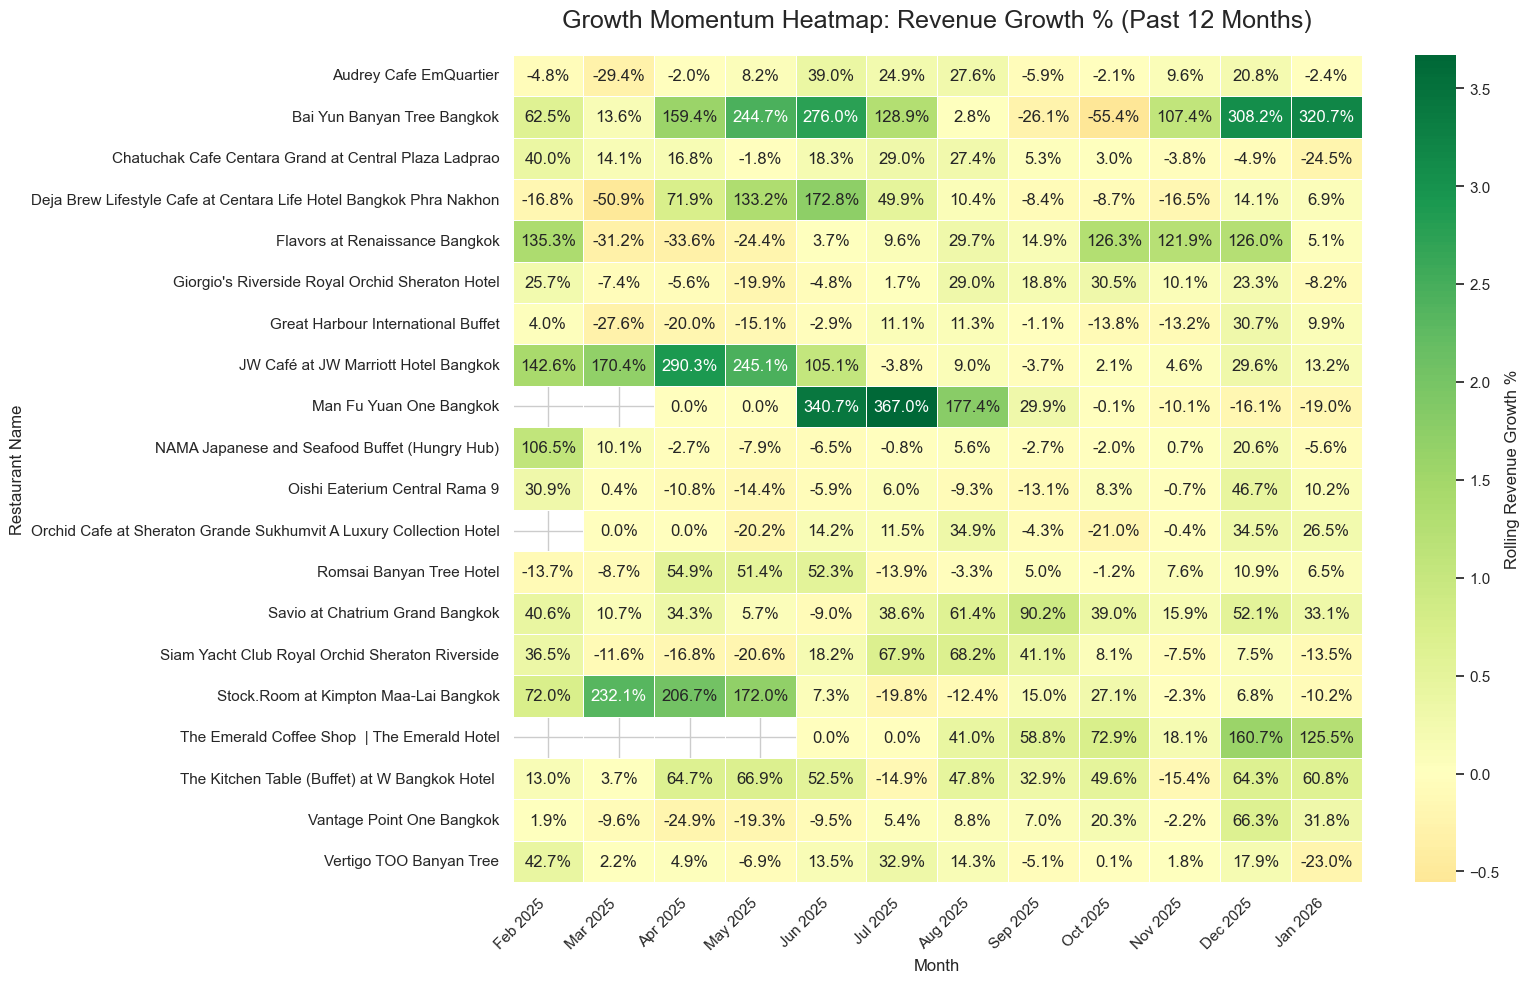

In [28]:
# 1. Filter for the Top 20 restaurants (by latest month volume) 

top_20_names = latest_growth.nlargest(20, "monthly_bookings")["name"].tolist()
growth_trend_df = last_12_months_df[last_12_months_df['name'].isin(top_20_names)]
print(growth_trend_df.shape)


# 2. Pivot the rolling growth data -- growth trend_df does not have the revenue_growth_rolling column yet, so we need to merge it
growth_trend_df = growth_trend_df.merge(
    restaurants_agg_active[['name', 'year_month', 'booking_growth_rolling', 'revenue_growth_rolling']],
    on=['name', 'year_month'],
    how='left'
)

print(f"Shape after correct merge: {growth_trend_df.shape}")

growth_heatmap = growth_trend_df.pivot(
    index='name', 
    columns='year_month', 
    values='revenue_growth_rolling'
)


# 3. Sort chronologically and format labels
growth_heatmap.columns = [d.strftime('%b %Y') for d in growth_heatmap.columns]

# 4. Plot using a Diverging Color Map (RdYlGn: Red-Yellow-Green)
plt.figure(figsize=(16, 10))
sns.heatmap(
    growth_heatmap, 
    annot=True, 
    fmt=".1%", 
    cmap="RdYlGn", 
    center=0, 
    linewidths=.5,
    cbar_kws={'label': 'Rolling Revenue Growth %'}
)

plt.title("Growth Momentum Heatmap: Revenue Growth % (Past 12 Months)", fontsize=18, pad=20)
plt.ylabel("Restaurant Name", fontsize=12)
plt.xlabel("Month", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

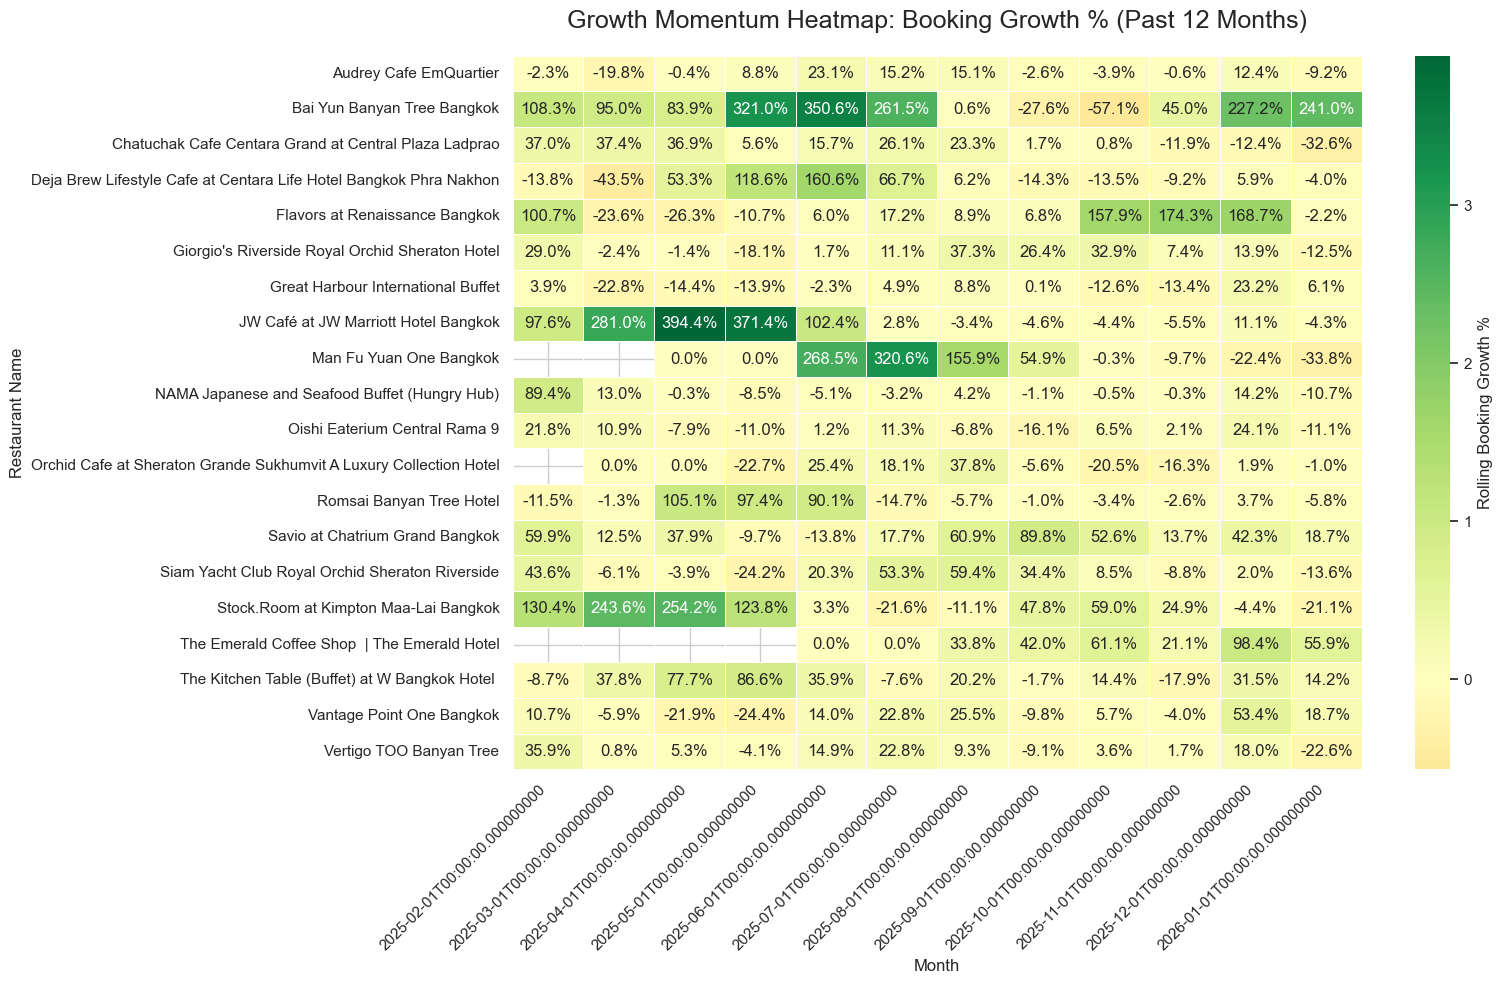

In [29]:
booking_growth_heatmap = growth_trend_df.pivot(
    index='name', 
    columns='year_month', 
    values='booking_growth_rolling'
)

# 4. Plot using a Diverging Color Map (RdYlGn: Red-Yellow-Green)
plt.figure(figsize=(16, 10))
sns.heatmap(
    booking_growth_heatmap, 
    annot=True, 
    fmt=".1%", 
    cmap="RdYlGn", 
    center=0, 
    linewidths=.5,
    cbar_kws={'label': 'Rolling Booking Growth %'}
)

plt.title("Growth Momentum Heatmap: Booking Growth % (Past 12 Months)", fontsize=18, pad=20)
plt.ylabel("Restaurant Name", fontsize=12)
plt.xlabel("Month", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5) Standardize into comparable scores

In [25]:
# def pct_rank(s: pd.Series) -> pd.Series:
#     return s.rank(pct=True, method="average")

# restaurants_agg["perf_bookings_rank"] = pct_rank(restaurants_agg["monthly_bookings"])
# restaurants_agg["perf_spend_rank"] = pct_rank(restaurants_agg["avg_revenue_per_booking"])
# restaurants_agg["performance_score"] = (restaurants_agg["perf_bookings_rank"] + restaurants_agg["perf_spend_rank"]) / 2

# restaurants_agg["growth_bookings_rank"] = pct_rank(restaurants_agg["booking_growth_rolling"])
# restaurants_agg["growth_revenue_rank"] = pct_rank(restaurants_agg["revenue_growth_rolling"])
# restaurants_agg["growth_score"] = (restaurants_agg["growth_bookings_rank"] + restaurants_agg["growth_revenue_rank"]) / 2

# restaurants_agg[["performance_score","growth_score"]].describe().T

In [30]:
restaurants_agg_active[['monthly_revenue', 'monthly_bookings', 'booking_growth_rolling', 'revenue_growth_rolling']].describe()

,monthly_revenue,monthly_bookings,booking_growth_rolling,revenue_growth_rolling
count,18334.000000,18334.000000,18334.000000,18334.000000
mean,3743.267192,13.133741,0.281189,0.405101
std,10418.296297,30.624447,0.691695,1.096167
min,18.900000,1.000000,-0.619248,-0.742750
25%,252.000000,1.000000,0.000000,0.000000
50%,737.020000,4.000000,0.057804,0.106123
75%,2700.360000,11.000000,0.391601,0.527739
max,199739.520000,447.000000,16.233333,36.326737


In [31]:
# 1. CALIBRATED PERFORMANCE SCORE (Log-Scale is Mandatory)
# ---------------------------------------------------------
# Use Log because Max (447) >> Median (3)
restaurants_agg_active['log_bookings'] = np.log1p(restaurants_agg_active['monthly_bookings'])
restaurants_agg_active['log_rev'] = np.log1p(restaurants_agg_active['monthly_revenue'])

restaurants_agg_active[['log_bookings', 'log_rev']].describe()

,log_bookings,log_rev
count,18334.000000,18334.000000
mean,1.816445,6.798181
std,1.106711,1.609396
min,0.693147,2.990720
25%,0.693147,5.533389
50%,1.609438,6.603971
75%,2.484907,7.901511
max,6.104793,12.204774


In [32]:


# Scale to 0-1
def min_max(s):
    return (s - s.min()) / (s.max() - s.min())

restaurants_agg_active['score_perf'] = (min_max(restaurants_agg_active['log_bookings']) * 0.5 + 
                                 min_max(restaurants_agg_active['log_rev']) * 0.5)


# 2. CALIBRATED MOMENTUM SCORE (Capped at 200%)
# ---------------------------------------------------------
# Your 75% percentile is 0.44. A restaurant doubling (1.0) is already elite.
# Let's cap at 2.0 (200%) to catch the 'super stars' but ignore the 3600% outlier.
# If we edit the rolling window and observe different growth rates, we may need to adjust this cap accordingly.
CAP_VALUE = 2.0 

restaurants_agg_active['revenue_growth_rolling'] = (
    restaurants_agg_active['revenue_growth_rolling']
    .replace([np.inf], CAP_VALUE)
    .replace([-np.inf], -1.0)
    .fillna(0)
    .clip(upper=CAP_VALUE, lower=-1.0)
)

restaurants_agg_active['booking_growth_rolling'] = (
    restaurants_agg_active['booking_growth_rolling']
    .replace([np.inf], CAP_VALUE)
    .replace([-np.inf], -1.0)
    .fillna(0)
    .clip(upper=CAP_VALUE, lower=-1.0)
)

# Scale Growth (Map -1.0 to 0, 0.0 to ~0.33, 2.0 to 1.0)
restaurants_agg_active['score_growth'] = (min_max(restaurants_agg_active['revenue_growth_rolling'] * 0.5 + 
                                    min_max(restaurants_agg_active['booking_growth_rolling']) * 0.5))

In [33]:
restaurants_agg_active

,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days,booking_growth_pct,revenue_growth_pct,booking_growth_rolling,revenue_growth_rolling,log_bookings,log_rev,score_perf,score_growth
0,Charoen Rung Rueang International Buffet MS S...,2024-08-01,7,3198.4,456.914286,2.285714,6,0.000000,0.000000,0.000000,0.000000,2.079442,8.070719,0.403750,0.254255
1,Charoen Rung Rueang International Buffet MS S...,2024-10-01,32,21789.1,680.909375,3.406250,19,3.571429,5.812500,0.000000,0.000000,3.496508,9.989211,0.638784,0.254255
2,Charoen Rung Rueang International Buffet MS S...,2024-11-01,21,12593.7,599.700000,3.000000,17,-0.343750,-0.422018,1.075893,1.796827,3.091042,9.441031,0.571575,0.849968
3,Charoen Rung Rueang International Buffet MS S...,2024-12-01,21,15592.2,742.485714,3.714286,11,0.000000,0.238095,1.075893,1.876192,3.091042,9.654590,0.583164,0.871385
4,Charoen Rung Rueang International Buffet MS S...,2025-01-01,20,10594.7,529.735000,2.650000,14,-0.047619,-0.320513,-0.130456,-0.168145,3.044522,9.268204,0.557899,0.195441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18425,sala ayutthaya staycation (Ayutthaya),2025-06-01,1,468.0,468.000000,2.000000,1,0.000000,-0.250000,0.000000,0.000000,0.693147,6.150603,0.171471,0.254255
18426,sala ayutthaya staycation (Ayutthaya),2025-10-01,1,468.0,468.000000,2.000000,1,0.000000,0.000000,0.000000,-0.083333,0.693147,6.150603,0.171471,0.231768
18427,sala bang pa-in Staycation (Ayutthaya),2025-09-01,2,1560.0,780.000000,3.500000,2,0.000000,0.000000,0.000000,0.000000,1.098612,7.353082,0.274186,0.254255
18428,sala bang pa-in Staycation (Ayutthaya),2025-10-01,1,2496.0,2496.000000,12.000000,1,-0.500000,0.600000,0.000000,0.000000,0.693147,7.822845,0.262215,0.254255


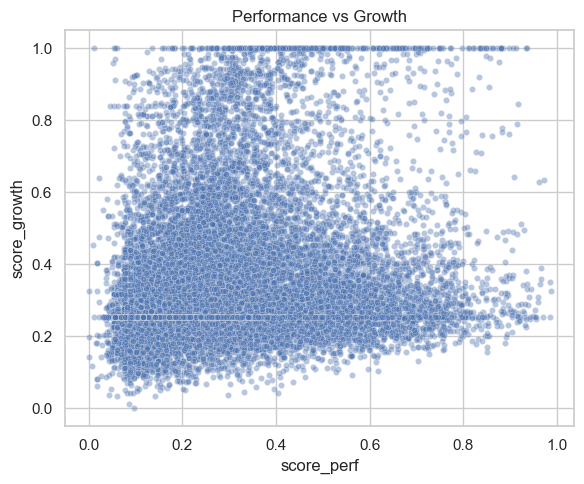

In [34]:
# Performance vs Growth scatter
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=restaurants_agg_active,
    x="score_perf",
    y="score_growth",
    alpha=0.4,
    s=20
)
plt.title("Performance vs Growth")
plt.tight_layout()

## 6) Composite momentum + segmentation

In [31]:
# # i think we may have to weigh the performance and growth scores (based on industry standards)
# perf_weight = 0.4
# restaurants_agg["momentum_score"] = perf_weight * restaurants_agg["performance_score"] + (1 - perf_weight) * restaurants_agg["growth_score"]

# perf_cut = restaurants_agg["performance_score"].median()
# grow_cut = restaurants_agg["growth_score"].median()

# restaurants_agg["momentum_segment"] = np.select(
#     [
#         (restaurants_agg["performance_score"] >= perf_cut) & (restaurants_agg["growth_score"] >= grow_cut),
#         (restaurants_agg["performance_score"] <  perf_cut) & (restaurants_agg["growth_score"] >= grow_cut),
#         (restaurants_agg["performance_score"] >= perf_cut) & (restaurants_agg["growth_score"] <  grow_cut),
#         (restaurants_agg["performance_score"] <  perf_cut) & (restaurants_agg["growth_score"] <  grow_cut),
#     ],
#     [
#         "Rising Stars",
#         "Emerging Opportunities",
#         "Established Players",
#         "Needs Attention",
#     ],
#     default="Unclassified"
# )

# restaurants_agg[["momentum_score","momentum_segment"]].head()

**Based on latest available record for a restaurant, we obtain their corresponding momentum segment**

However, we need to consider the following that a restaurant may have last available record back in 2024, which will not be useful for us. Would be good to apply a recency filter to remove old records and solely consider more recent ones, e.g. must have booking data within the last 12 months.

In [35]:
# 1. Prepare Data (Latest Snapshot)
latest = restaurants_agg_active.sort_values("year_month").groupby("name").tail(1)
latest['name'].nunique()

# 2. Calculate the 75th Percentile Thresholds dynamically
# This ensures "Big" and "Fast" are defined relative to YOUR specific data
perf_threshold = latest['score_perf'].quantile(0.75)
growth_threshold = latest['score_growth'].quantile(0.75)

print(f"Performance Cutoff (75th%): {perf_threshold:.3f}")
print(f"Growth Cutoff (75th%): {growth_threshold:.3f}")

# 3. Define the Segmentation Logic using these variables
def get_segment(row):
    is_big = row['score_perf'] >= perf_threshold
    is_growing = row['score_growth'] >= growth_threshold
    
    if is_big and is_growing: 
        return "Rising Stars"         # High Perf + High Growth
    if not is_big and is_growing: 
        return "Emerging Opportunities" # Low Perf + High Growth
    if is_big and not is_growing: 
        return "Established Players"  # High Perf + Low Growth
    return "Needs Attention"          # Low Perf + Low Growth

# 4. Apply the function
latest['segment'] = latest.apply(get_segment, axis=1)

# 4. Verify the balance
# Since you used 75th percentile (Top 25%), your "Rising Stars" (Top 25% of both) 
# will likely be a very elite, small group (approx 6% of total if independent).
print(latest['segment'].value_counts())

Performance Cutoff (75th%): 0.259
Growth Cutoff (75th%): 0.411
segment
Needs Attention           1008
Emerging Opportunities     261
Established Players        261
Rising Stars               163
Name: count, dtype: int64


In [36]:
latest

,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days,booking_growth_pct,revenue_growth_pct,booking_growth_rolling,revenue_growth_rolling,log_bookings,log_rev,score_perf,score_growth,segment
18100,Yurijin Izakaya & Japanese Dining Ratchada,2025-01-01,1,162.00,162.000000,2.000000,1,-0.666667,-0.776119,0.277778,-0.130664,0.693147,5.093750,0.114121,0.247614,Needs Attention
8423,MJ Hotpot,2025-01-01,1,426.00,426.000000,4.000000,1,-0.666667,-0.798066,0.222222,1.627313,0.693147,6.056784,0.166380,0.716276,Emerging Opportunities
12922,Shabushi Seacon Square,2025-01-01,2,310.80,155.400000,3.500000,2,-0.500000,-0.300000,0.611111,1.571462,1.098612,5.742362,0.186780,0.741270,Emerging Opportunities
9070,Melody Bangkok,2025-01-01,1,202.80,202.800000,4.000000,1,0.000000,0.000000,0.000000,0.000000,0.693147,5.317139,0.126243,0.254255,Needs Attention
10883,Patong Bay Hill Resort (Phuket),2025-01-01,2,195.00,97.500000,2.000000,2,1.000000,1.000000,0.333333,0.333333,1.098612,5.278115,0.161588,0.378546,Needs Attention
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4985,Food Exchange Restaurant at Novotel Bangkok Su...,2026-01-01,6,1593.72,265.620000,6.333333,3,-0.714286,-0.438839,-0.317950,-0.243448,1.945910,7.374453,0.353630,0.155805,Established Players
11290,"Praya Dining at Praya Palazzo, Bangkok",2026-01-01,5,1262.40,252.480000,2.400000,5,-0.615385,-0.659877,0.332751,0.745006,1.791759,7.141562,0.326750,0.489575,Rising Stars
13752,Streats Cafe at ibis Styles Bangkok Ratchada,2026-01-01,5,208.00,41.600000,1.600000,3,-0.954545,-0.976739,-0.466132,-0.468366,1.791759,5.342334,0.229115,0.079844,Needs Attention
13721,Stella Palace 79th floor at Baiyoke Sky Hotel ...,2026-01-01,2,945.00,472.500000,3.500000,2,-0.857143,-0.882718,0.380952,1.159319,1.098612,6.852243,0.247008,0.606342,Emerging Opportunities


In [37]:
# 2. Create "Previous Month" versions of your Key Metrics
cols_to_shift = [
    'booking_growth_rolling', 'revenue_growth_rolling', # Speed
    'log_bookings', 'log_rev'                           # Size
]

for col in cols_to_shift:
    restaurants_agg_active[f'{col}_prev'] = restaurants_agg_active.groupby("name")[col].shift(1).replace(np.nan, 0.0)

# 3. Calculate the "Delta" (Change in position)
# How much did their speed change? (Acceleration)
restaurants_agg_active['delta_growth_book'] = restaurants_agg_active['booking_growth_rolling'] - restaurants_agg_active['booking_growth_rolling_prev']
restaurants_agg_active['delta_growth_rev'] = restaurants_agg_active['revenue_growth_rolling'] - restaurants_agg_active['revenue_growth_rolling_prev']

# How much did their size change? (Expansion)
restaurants_agg_active['delta_size_book'] = restaurants_agg_active['log_bookings'] - restaurants_agg_active['log_bookings_prev']
restaurants_agg_active['delta_size_rev'] = restaurants_agg_active['log_rev'] - restaurants_agg_active['log_rev_prev']

C:\Users\foogu\AppData\Local\Temp\ipykernel_15972\671550582.py:73: UserWarning: Glyph 22812 (\N{CJK UNIFIED IDEOGRAPH-591C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\foogu\AppData\Local\Temp\ipykernel_15972\671550582.py:73: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\foogu\AppData\Local\Temp\ipykernel_15972\671550582.py:73: UserWarning: Glyph 39321 (\N{CJK UNIFIED IDEOGRAPH-9999}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\foogu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22812 (\N{CJK UNIFIED IDEOGRAPH-591C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\foogu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarn

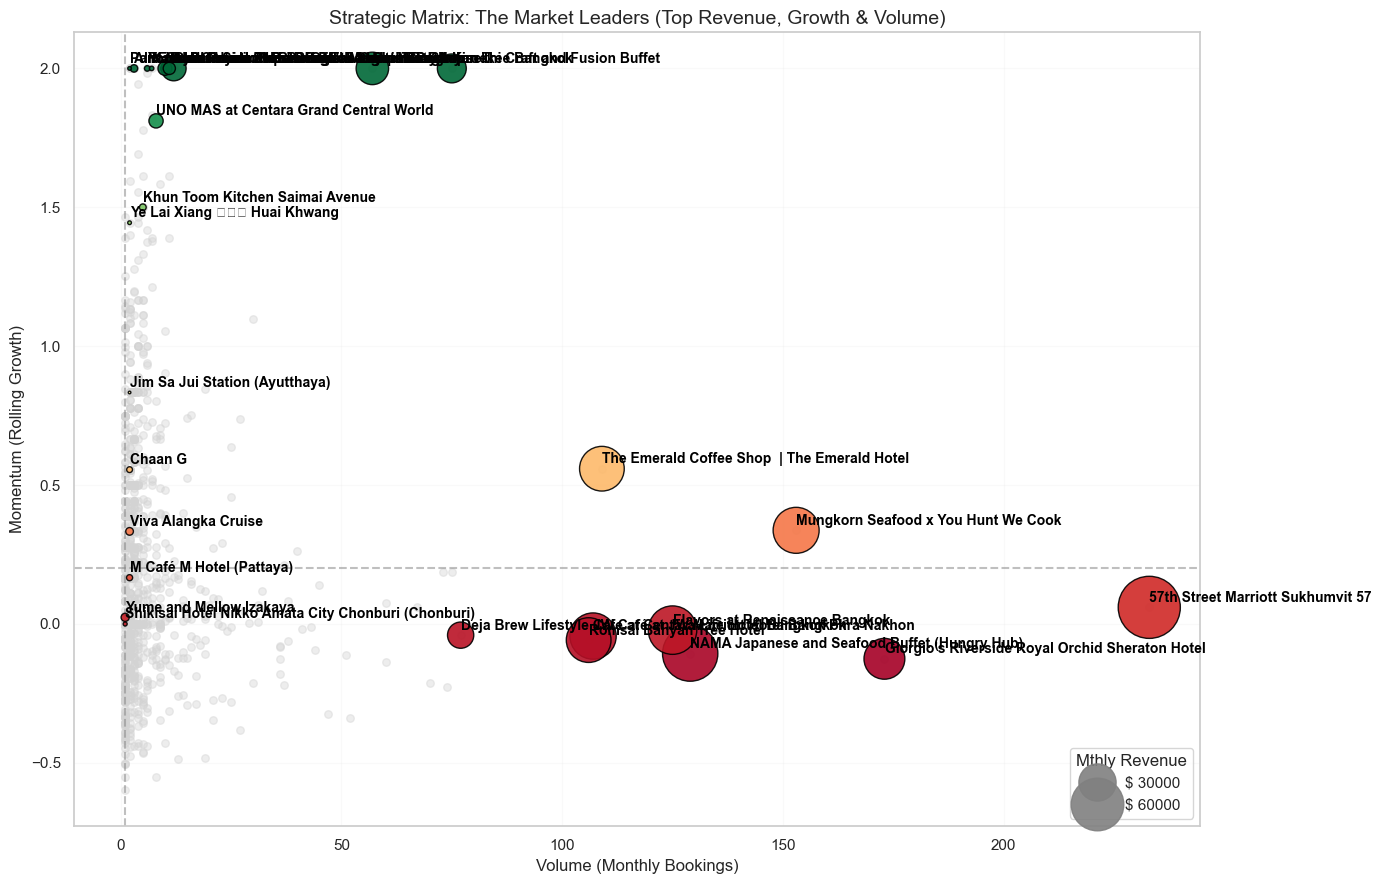

In [40]:
# Filter for latest month & meaningful movers (e.g., top 15 by growth change)
latest = restaurants_agg_active.sort_values("year_month").groupby("name").tail(1)

# 2. Identify the "VIPs" (The ones we want to label)
# We pick the top 5 from 3 different categories to cover "All Sides"
top_revenue_growth = latest.nlargest(10, "revenue_growth_rolling")      # The "Giants" (Big $)
top_booking_growth  = latest.nlargest(10, "booking_growth_rolling") # The "Rockets" (Fast)
top_volume  = latest.nlargest(10, "monthly_bookings")       # The "Popular" (Busy)


# Combine them and drop duplicates (some might be top in multiple categories)
highlights = pd.concat([top_revenue_growth, top_booking_growth, top_volume]).drop_duplicates()

# 3. Setup the Plot
plt.figure(figsize=(14, 9))

# --- LAYER 1: The "Noise" (Background Context) ---
# Plot ALL restaurants as faint grey dots. This shows the market density without clutter.
plt.scatter(
    latest["monthly_bookings"], 
    latest["booking_growth_rolling"], 
    c="lightgrey", 
    s=30, 
    alpha=0.4, 
    label="Others"
)

# --- LAYER 2: The "VIPs" (Highlights) ---
# Scale bubble size for the highlights only
# We use a larger scaling factor here to make them pop
bubble_size = highlights["monthly_revenue"] / highlights["monthly_revenue"].max() * 2000

scatter = plt.scatter(
    highlights["monthly_bookings"],
    highlights["booking_growth_rolling"], 
    s=bubble_size, 
    c=highlights["booking_growth_rolling"], 
    cmap="RdYlGn",          # Red=Slow, Green=Fast
    edgecolors="black",     # distinct border
    alpha=0.9,
    zorder=10               # Force these to sit On Top of the grey dots
)

# 4. Smart Labeling (Only label the Highlights)
# We add a small offset so the text doesn't sit directly on the bubble center
for i, row in highlights.iterrows():
    plt.text(
        row["monthly_bookings"] + 0.05,  # Shift text slightly right
        row["booking_growth_rolling"] + 0.02, # Shift text slightly up
        row["name"], 
        fontsize=10, 
        fontweight='bold', 
        color='black',
        zorder=11 # Text on top of bubbles
    )

# 5. Add Reference Lines (Quadrants)
plt.axhline(0.2, color='gray', linestyle='--', alpha=0.5) # Growth Threshold
plt.axvline(latest["monthly_bookings"].median(), color='gray', linestyle='--', alpha=0.5) # Volume Threshold

# 6. Formatting
plt.title("Strategic Matrix: The Market Leaders (Top Revenue, Growth & Volume)", fontsize=14)
plt.xlabel("Volume (Monthly Bookings)")
plt.ylabel("Momentum (Rolling Growth)")
plt.grid(True, alpha=0.1)

# Custom Legend for Size
# Create dummy points for the legend key
kw = dict(prop="sizes", num=3, color='grey', fmt="$ {x:.0f}", 
          func=lambda s: s/2000 * highlights["monthly_revenue"].max())
plt.legend(*scatter.legend_elements(**kw), title="Mthly Revenue", loc="lower right")

plt.tight_layout()
plt.show()

In [41]:
restaurants_agg_active

,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days,booking_growth_pct,revenue_growth_pct,booking_growth_rolling,...,score_perf,score_growth,booking_growth_rolling_prev,revenue_growth_rolling_prev,log_bookings_prev,log_rev_prev,delta_growth_book,delta_growth_rev,delta_size_book,delta_size_rev
0,Charoen Rung Rueang International Buffet MS S...,2024-08-01,7,3198.4,456.914286,2.285714,6,0.000000,0.000000,0.000000,...,0.403750,0.254255,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.079442,8.070719
1,Charoen Rung Rueang International Buffet MS S...,2024-10-01,32,21789.1,680.909375,3.406250,19,3.571429,5.812500,0.000000,...,0.638784,0.254255,0.000000,0.000000,2.079442,8.070719,0.000000,0.000000,1.417066,1.918492
2,Charoen Rung Rueang International Buffet MS S...,2024-11-01,21,12593.7,599.700000,3.000000,17,-0.343750,-0.422018,1.075893,...,0.571575,0.849968,0.000000,0.000000,3.496508,9.989211,1.075893,1.796827,-0.405465,-0.548180
3,Charoen Rung Rueang International Buffet MS S...,2024-12-01,21,15592.2,742.485714,3.714286,11,0.000000,0.238095,1.075893,...,0.583164,0.871385,1.075893,1.796827,3.091042,9.441031,0.000000,0.079365,0.000000,0.213559
4,Charoen Rung Rueang International Buffet MS S...,2025-01-01,20,10594.7,529.735000,2.650000,14,-0.047619,-0.320513,-0.130456,...,0.557899,0.195441,1.075893,1.876192,3.091042,9.654590,-1.206349,-2.044338,-0.046520,-0.386387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18425,sala ayutthaya staycation (Ayutthaya),2025-06-01,1,468.0,468.000000,2.000000,1,0.000000,-0.250000,0.000000,...,0.171471,0.254255,0.000000,0.000000,0.693147,6.437752,0.000000,0.000000,0.000000,-0.287149
18426,sala ayutthaya staycation (Ayutthaya),2025-10-01,1,468.0,468.000000,2.000000,1,0.000000,0.000000,0.000000,...,0.171471,0.231768,0.000000,0.000000,0.693147,6.150603,0.000000,-0.083333,0.000000,0.000000
18427,sala bang pa-in Staycation (Ayutthaya),2025-09-01,2,1560.0,780.000000,3.500000,2,0.000000,0.000000,0.000000,...,0.274186,0.254255,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612,7.353082
18428,sala bang pa-in Staycation (Ayutthaya),2025-10-01,1,2496.0,2496.000000,12.000000,1,-0.500000,0.600000,0.000000,...,0.262215,0.254255,0.000000,0.000000,1.098612,7.353082,0.000000,0.000000,-0.405465,0.469763


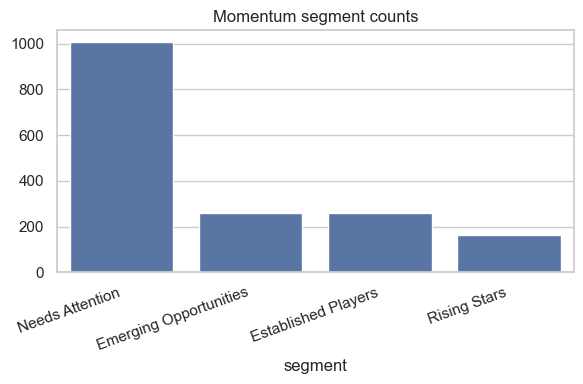

In [42]:
latest['segment'] = latest.apply(get_segment, axis=1)
 # Segment counts
plt.figure(figsize=(6, 4))
segment_counts = latest['segment'].value_counts()
sns.barplot(x=segment_counts.index, y=segment_counts.values)
plt.title("Momentum segment counts")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [43]:
restaurants_agg_active.to_parquet("restaurants_agg_performance.parquet")

## 7) Latest-month prioritised list

In [47]:
# latest_month = restaurants_agg["year_month"].max()
# priority_latest = (
#     restaurants_agg[restaurants_agg["year_month"] == latest_month]
#     .sort_values("momentum_score", ascending=False)
#     .reset_index(drop=True)
# )

# print("Latest month:", latest_month.date())
# print(priority_latest["momentum_segment"].value_counts(dropna=False))
# priority_latest.head(10)

In [44]:
# Save latest-month list
output_path = BASE_DIR / "priority_latest_momentum_labels.parquet"
latest.to_parquet(output_path, index=False)
print("Saved latest-month momentum labels to:", output_path)

Saved latest-month momentum labels to: priority_latest_momentum_labels.parquet
